# DarkNESS ALP: Yamamoto Geometry Validation

Primary notebook interface for the Suzaku `101002010` vertical slice. The tested implementation remains in `darkness_alp`; this notebook supplies configuration, execution, and inline results.

In [1]:
from pathlib import Path
import json
import sys

from IPython.display import Image, Markdown, display
from astropy.table import Table

ROOT = Path.cwd().resolve()
if not (ROOT / "src").is_dir():
    raise RuntimeError("Open this notebook from the ALP project directory.")

OBS_ID = "101002010"
XIS = 0
CADENCE_S = 60.0
Q_PER_M = 0.0
INITIAL_INTERVALS = 32
MAX_INTERVALS = 256
RELATIVE_TOLERANCE = 0.01
MAX_SAMPLES = None  # Set to a small integer for a quick smoke run.
RUN_VALIDATION = True  # False loads the most recent saved result.

print(f"Python: {sys.executable}")
print(f"Project: {ROOT}")

Python: c:\Users\phial\Documents\Python\darkmatter\ALP\.venv\Scripts\python.exe
Project: C:\Users\phial\Documents\Python\darkmatter\ALP


In [2]:
import forms
import darkness_alp

expected_environment = ROOT / ".venv"
active_environment = Path(sys.executable).resolve().parents[1]
if active_environment != expected_environment:
    raise RuntimeError(
        "Select the 'DarkNESS ALP (.venv)' kernel before running this notebook. "
        f"Active interpreter: {sys.executable}"
    )

print(f"darkness_alp {darkness_alp.__version__}")
print(f"FORMS {forms.__version__}")
print(forms.__file__)

darkness_alp 0.1.0
FORMS 20260708.2057
C:\Users\phial\Documents\Python\forms\python\src\forms\__init__.py


In [3]:
from darknessalp.yamamoto.validation import validate_observation

output_dir = ROOT / "outputs" / f"yamamoto_{OBS_ID}"
if RUN_VALIDATION:
    summary = validate_observation(
        OBS_ID,
        data_root=ROOT / "data" / "suzaku",
        output_root=ROOT / "outputs",
        xis=XIS,
        cadence_s=CADENCE_S,
        q_per_m=Q_PER_M,
        initial_intervals=INITIAL_INTERVALS,
        max_intervals=MAX_INTERVALS,
        relative_tolerance=RELATIVE_TOLERANCE,
        max_samples=MAX_SAMPLES,
    )
else:
    summary = json.loads((output_dir / "summary.json").read_text(encoding="utf-8"))

gate = summary["acceptance"]
status = "PASS" if gate["vertical_slice_pass"] else "FAIL"
raw = summary["b_perp_l_squared_t2m2"]
screened = summary["yamamoto_screen"]
display(Markdown(
    f"## Validation: **{status}**\n"
    f"- Samples: **{summary['sample_count']:,}**  \n"
    f"- GTI exposure: **{summary['gti_exposure_s'] / 1000:.3f} ks**  \n"
    f"- Raw median: **{raw['median']:.3g} T² m²**  \n"
    f"- Screened median: **{screened['median_t2m2']:.3g} T² m²**  \n"
    f"- Converged: **{100 * summary['converged_fraction']:.1f}%**  \n"
    f"- BGCRS cross-check: **{'PASS' if summary['bgcrs_crosscheck']['pass'] else 'FAIL'}**"
))
summary

[2026-07-30 20:03:01.789] [FORMS] [WARNING] EOP data is 34 days old - consider updating (C:\Users\phial\Documents\Python\forms\resources\vallado\software\datalib\EOP-All-v1.1_2026-06-28.txt)
[2026-07-30 20:03:01.791] [FORMS] [INFO] IAU/EOP data directory: C:\Users\phial\Documents\Python\forms\resources\vallado\software\datalib


## Validation: **PASS**
- Samples: **999**  
- GTI exposure: **59.001 ks**  
- Raw median: **1.64e+04 T² m²**  
- Screened median: **1.57e+04 T² m²**  
- Converged: **100.0%**  
- BGCRS cross-check: **PASS**

{'obsid': '101002010',
 'sample_count': 999,
 'valid_integral_count': 999,
 'valid_integral_fraction': 1.0,
 'converged_count': 999,
 'converged_fraction': 1.0,
 'sample_exposure_s': 59001.074851453304,
 'gti_exposure_s': 59001.074851453304,
 'b_perp_l_squared_t2m2': {'minimum': 997.1673290608171,
  'p05': 2501.9764751370626,
  'median': 16405.834062389185,
  'p95': 49296.16535727182,
  'maximum': 62364.348216360784},
 'yamamoto_screen': {'criterion': 'SAA == 0, COR2 >= 8 GV, ELV >= 5 deg, DYE_ELV >= 20 deg',
  'sample_count': 698,
  'exposure_s': 41298.71343293786,
  'minimum_t2m2': 3604.6436890668797,
  'median_t2m2': 15701.507290318861,
  'maximum_t2m2': 62364.348216360784},
 'bgcrs_crosscheck': {'sample_id': 0,
  'maximum_absolute_difference_t': 0.0,
  'relative_vector_difference': 0.0,
  'pass': True},
 'quality_flag_counts': {'cor2_below_8_gv': 300, 'saa': 8},
 'acceptance': {'geometry_scale_pass': True,
  'numerical_convergence_pass': True,
  'bgcrs_crosscheck_pass': True,
  've

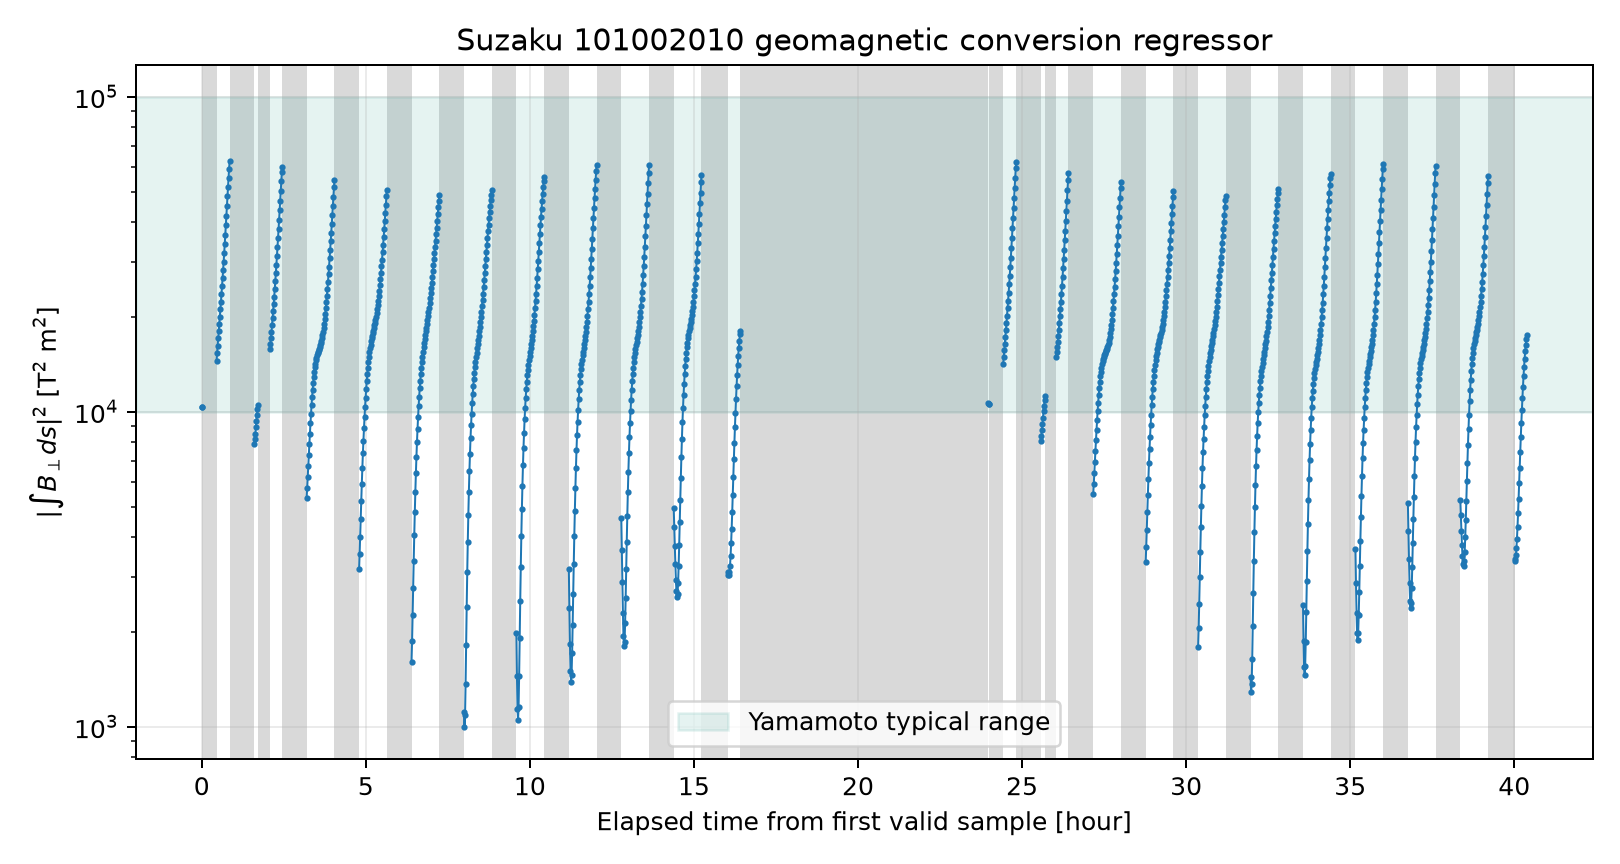

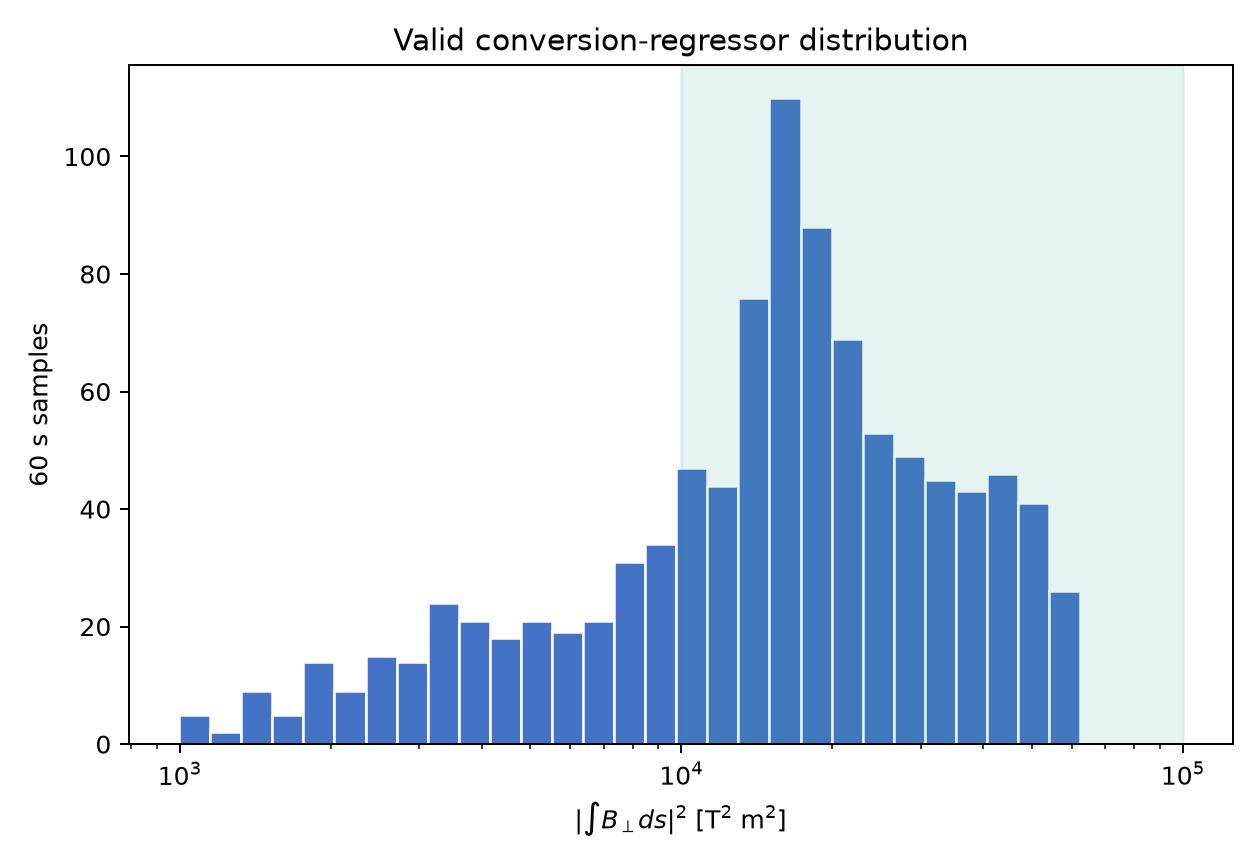

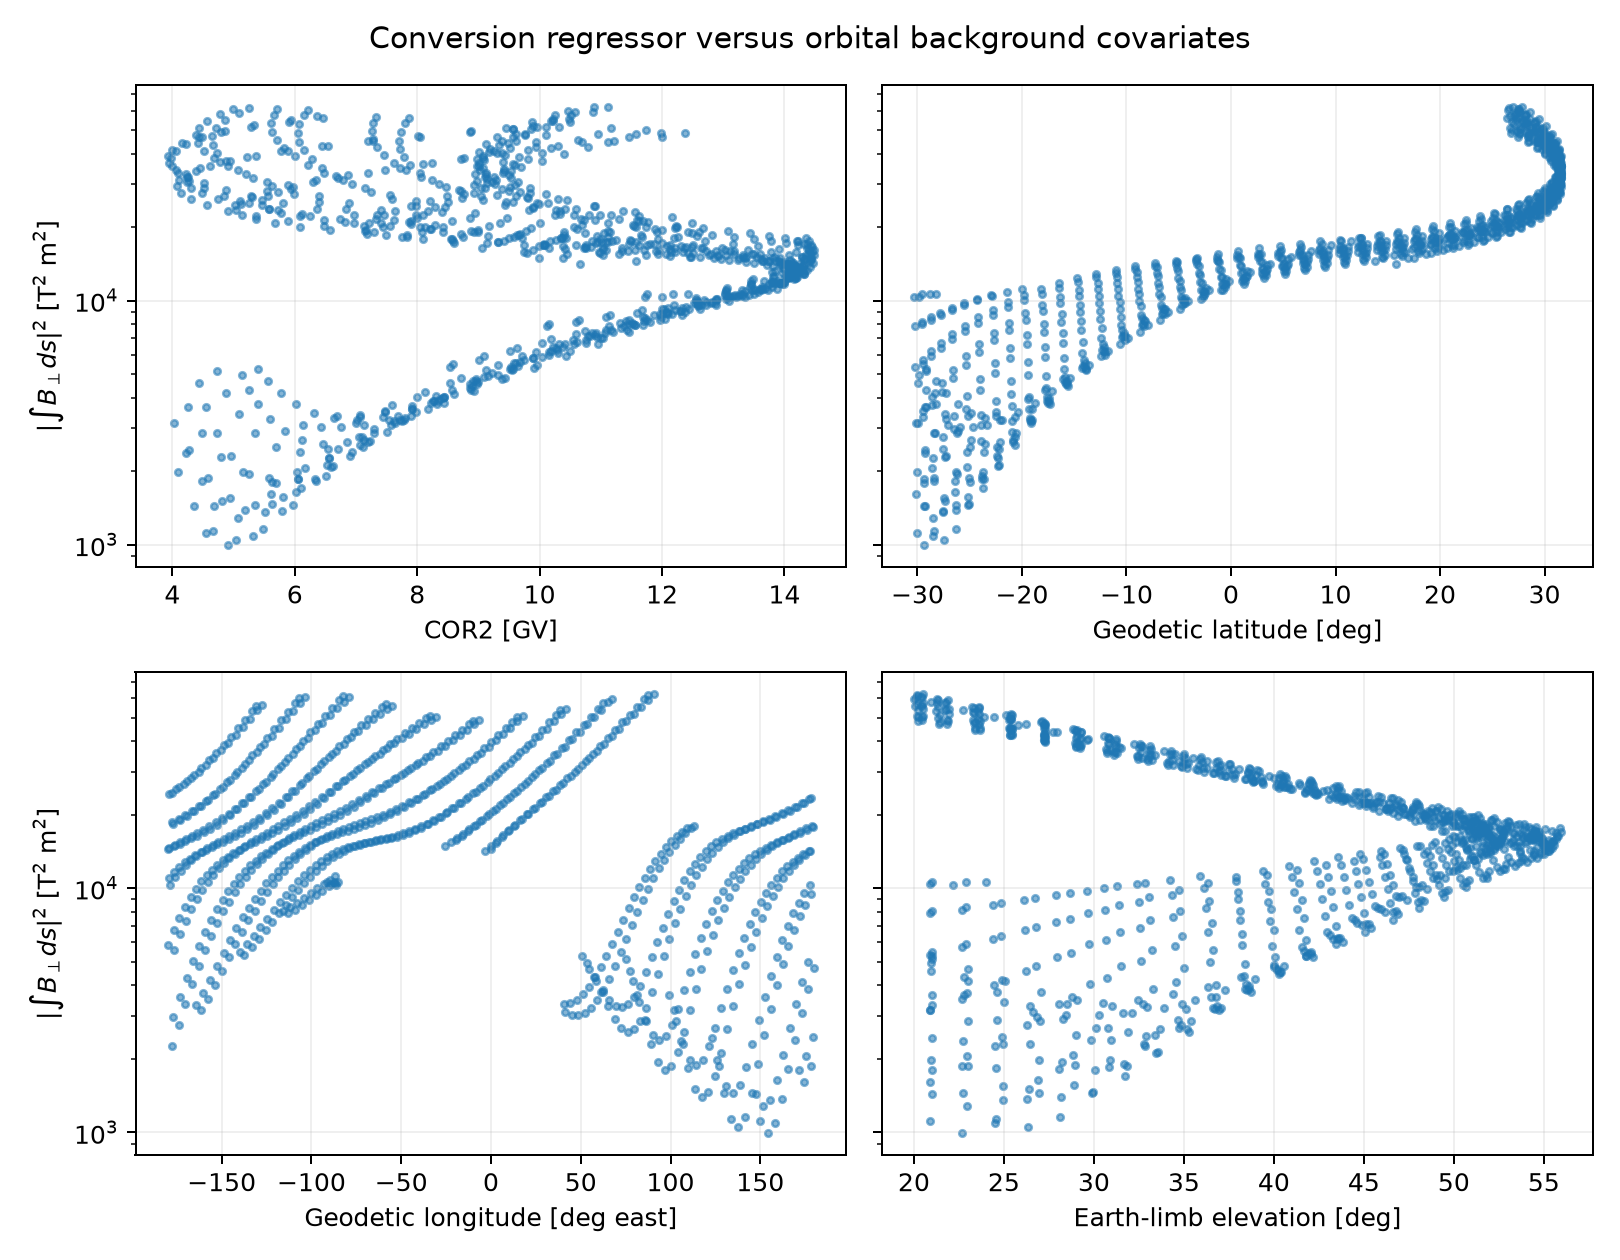

In [4]:
for filename in (
    "field_integral_time.png",
    "field_integral_histogram.png",
    "field_integral_covariates.png",
):
    display(Image(filename=str(output_dir / filename)))

In [5]:
state_table = Table.read(output_dir / "frame_state.csv", format="ascii.csv")
display(state_table[:10])
print(f"Rows: {len(state_table):,}")
print(f"Columns: {len(state_table.colnames)}")

mission,obsid,sample_id,gti_index,mission_time_tt_s,utc,mjd_tt,mjd2000_tt,exposure_s,latitude_deg,longitude_deg,altitude_km,r_itrf_x_km,r_itrf_y_km,r_itrf_z_km,r_gcrf_x_km,r_gcrf_y_km,r_gcrf_z_km,boresight_gcrf_x,boresight_gcrf_y,boresight_gcrf_z,foc_ra_deg,foc_dec_deg,foc_roll_deg,earth_limb_elevation_deg,day_earth_limb_elevation_deg,night_earth_limb_elevation_deg,cor2_gv,saa,pointing_separation_deg,ehk_nearest_offset_s,in_cleaned_gti,data_valid,quality_flags,b_integral_gcrf_x_tm_real,b_integral_gcrf_y_tm_real,b_integral_gcrf_z_tm_real,b_integral_gcrf_x_tm_imag,b_integral_gcrf_y_tm_imag,b_integral_gcrf_z_tm_imag,b_perp_l_tm,b_perp_l_squared_t2m2,los_exit_distance_km,integration_intervals,integration_relative_change,integration_converged,earth_intersection_geometry,q_per_m,yamamoto_screen_pass
str6,int64,int64,int64,float64,str23,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,str4,str4,str19,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,str4,str5,float64,str5
Suzaku,101002010,0,0,201221002.0,2006-05-17T22:43:21.000,53872.94752527778,2328.447525277734,60.0,-30.290433883666992,-89.04531860351562,571.2925415039062,100.05914169170829,-6004.553956604273,-3486.3658953454365,-3655.6572793674814,4766.049505519164,-3484.303254968482,-0.5170548474381487,0.15876819830696792,0.8410986529219222,162.93023681640625,57.256317138671875,281.8711242675781,20.873550415039062,20.873550415039062,26.576984405517578,11.72249698638916,0,0.20948205888271332,0.0,True,True,--,77.39914267360186,-37.61771042579066,54.680979283351846,0.0,0.0,0.0,101.95944742726674,10395.72891967357,37876.05571978185,64,0.006263985664944299,True,False,0.0,True
Suzaku,101002010,1,0,201221046.18070924,2006-05-17T22:44:05.181,53872.94803662858,2328.4480366287753,28.361418515443802,-29.808643892167083,-86.09177351562175,570.8949019972424,411.281696964469,-6020.159504450418,-3435.7805780932335,-3929.814028398216,4580.76633198176,-3433.540852832874,-0.5170528481377553,0.1587710501083453,0.8410993436450469,162.9298858642578,57.256390307270976,281.8712463378906,22.151461998813147,22.151461998813147,24.7960928976986,12.002820791293516,2,0.2214777476019556,0.18070924282073975,True,True,saa,78.13890876379476,-35.078076686287616,54.65624096047286,0.0,0.0,0.0,101.60445464021244,10323.465202734988,37720.21384212837,64,0.006281491692918668,True,False,0.0,False
Suzaku,101002010,2,1,201222625.0,2006-05-17T23:10:24.000,53872.966309999996,2328.466310000047,60.0,13.824226379394531,-0.223968505859375,560.6459350585938,6738.921969003082,-26.342498258470986,1648.067999043661,-4921.600014853837,-4602.276492943141,1651.3012254862374,-0.5170438262733413,0.15869399714429783,0.8411194308675721,162.93740844726562,57.25851821899414,281.87350463867193,50.74354553222656,200.0,50.74354553222656,11.580035209655762,0,0.17176499962806702,0.0,True,True,--,90.88877240455352,65.74767506719387,43.46554834938281,0.0,0.0,0.0,120.30286621382123,14472.779619260571,34525.36384897638,64,0.003848715189506037,True,False,0.0,True
Suzaku,101002010,3,1,201222685.0,2006-05-17T23:11:24.000,53872.96700444444,2328.46700444445,60.0,15.604873657226562,2.9527719020843506,560.9132690429688,6675.8880318782785,344.35074987813204,1855.5438338424835,-4600.204628836167,-4849.006797776952,1858.588663576573,-0.5170443108763273,0.1586920365210394,0.8411195028860222,162.9376220703125,57.25852584838867,281.87350463867193,50.45903015136719,200.0,50.45903015136719,11.028690338134766,0,0.17357578873634338,0.0,True,True,--,90.45942747186325,73.46406211229558,41.74599517817439,0.0,0.0,0.0,123.78450853799383,15322.604553992667,34553.72269349107,64,0.003429756232155698,True,False,0.0,True
Suzaku,101002010,4,1,201222745.0,2006-05-17T23:12:24.000,53872.96769888889,2328.467698888853,60.0,17.331010818481445,6.187952518463135,561.2249145507812,6587.516036605971,714.2

Rows: 999
Columns: 49


## Interpretation

A passing result validates the archived-state geometry scale, numerical convergence, and FORMS field interface for this observation. It does not yet reproduce all Yamamoto fields, IGRF-12, the spectral likelihood, or Figure 7.